In [ ]:
!pip install torch-geometric -q
!pip install torch-scatter torch-sparse -q
!pip install scikit-learn matplotlib seaborn -q
print("✅ Dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Dependencies installed


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── CHANGE THIS PATH to where you uploaded colab_data/ ──────────
DATA_DIR   = '/content/drive/MyDrive/pharmasafe-kg/colab_data'
OUTPUT_DIR = '/content/drive/MyDrive/pharmasafe-kg/model_output'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Data dir  : {DATA_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data dir  : /content/drive/MyDrive/pharmasafe-kg/colab_data
Output dir: /content/drive/MyDrive/pharmasafe-kg/model_output


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATConv
from torch_geometric.utils import negative_sampling

# For running locally (not in Colab), set these paths:
DATA_DIR = "/content/drive/MyDrive/pharmasafe-kg/colab_data"
OUTPUT_DIR = "/content/drive/MyDrive/pharmasafe-kg/model_output"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cpu
PyTorch version: 2.11.0+cpu


In [ ]:
print("Loading graph data...")
nodes_df   = pd.read_csv(f"{DATA_DIR}/nodes.csv")
edges_df   = pd.read_csv(f"{DATA_DIR}/edges.csv")
features_df= pd.read_csv(f"{DATA_DIR}/node_features.csv")

# Keep only positive edges for graph structure
pos_edges = edges_df[edges_df["label"] == 1].reset_index(drop=True)
neg_edges = edges_df[edges_df["label"] == 0].reset_index(drop=True)

num_nodes = len(nodes_df)
num_edges = len(pos_edges)

print(f"Nodes: {num_nodes:,}")
print(f"Positive edges: {num_edges:,}")
print(f"Negative edges: {len(neg_edges):,}")
print(f"Edge density: {num_edges / (num_nodes*(num_nodes-1)/2)*100:.2f}%")

# Severity distribution
sev_counts = pos_edges["severity"].value_counts()
print(f"\nSeverity distribution:\n{sev_counts.to_string()}")

Loading graph data...
Nodes: 2,073
Positive edges: 100,000
Negative edges: 50,000
Edge density: 4.66%

Severity distribution:
severity
MAJOR       87868
MODERATE    12132


In [ ]:
# Node feature matrix
feat_cols  = [c for c in features_df.columns if c not in ["node_id", "name"]]
x          = torch.tensor(features_df[feat_cols].values, dtype=torch.float)

# Add degree as a feature (computed from edge list)
degree = torch.zeros(num_nodes)
for _, row in pos_edges.iterrows():
    degree[int(row["node1"])] += 1
    degree[int(row["node2"])] += 1
degree = (degree / degree.max()).unsqueeze(1)  # normalise
x = torch.cat([x, degree], dim=1)

print(f"Node feature matrix shape: {x.shape}")  # [num_nodes, num_features]

# Edge index for positive edges (both directions — undirected graph)
edge_index = torch.tensor(
    [pos_edges["node1"].tolist() + pos_edges["node2"].tolist(),
     pos_edges["node2"].tolist() + pos_edges["node1"].tolist()],
    dtype=torch.long
)

# Severity labels for edges (for multi-class prediction)
sev_labels = torch.tensor(pos_edges["severity_label"].tolist(), dtype=torch.long)

graph_data = Data(x=x, edge_index=edge_index)
graph_data = graph_data.to(device)

print(f"Graph: {graph_data}")


Node feature matrix shape: torch.Size([2073, 10])
Graph: Data(x=[2073, 10], edge_index=[2, 200000])


In [ ]:
all_pairs  = pd.concat([pos_edges, neg_edges], ignore_index=True)
all_pairs  = all_pairs.sample(frac=1, random_state=42).reset_index(drop=True)

X = all_pairs[["node1", "node2"]].values
y = all_pairs["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Positive rate — Train: {y_train.mean():.2%}  Val: {y_val.mean():.2%}  Test: {y_test.mean():.2%}")

Train: 105,000  Val: 22,500  Test: 22,500
Positive rate — Train: 66.67%  Val: 66.67%  Test: 66.67%


In [ ]:
class GraphSAGE_DDI(nn.Module):
    """
    GraphSAGE for drug-drug interaction link prediction.

    Architecture:
        Input features → SAGEConv(128) → ReLU → Dropout
        → SAGEConv(64) → ReLU → Dropout
        → SAGEConv(32) → [node embeddings]
        → Dot product of node pairs → Sigmoid [link probability]

    SAGEConv aggregates neighbour embeddings by sampling and averaging,
    enabling inductive learning — the model generalises to unseen drug pairs.
    """

    def __init__(self, in_channels: int, hidden: int = 128, out: int = 64):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, hidden // 2)
        self.conv3 = SAGEConv(hidden // 2, out)
        self.dropout = nn.Dropout(p=0.3)
        self.bn1    = nn.BatchNorm1d(hidden)
        self.bn2    = nn.BatchNorm1d(hidden // 2)

    def encode(self, x, edge_index):
        """Returns node embeddings for all nodes."""
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        return x

    def decode(self, z, edge_index):
        """
        Link prediction: dot product of source and target embeddings.
        High dot product = likely interaction.
        """
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)

    def forward(self, x, edge_index, pred_edges):
        z = self.encode(x, edge_index)
        return self.decode(z, pred_edges)


class GAT_DDI(nn.Module):
    """
    Graph Attention Network for DDI prediction.
    Uses attention weights to learn which neighbour connections matter most.
    Compared against GraphSAGE in paper experiments (Table 2).
    """

    def __init__(self, in_channels: int, hidden: int = 64, out: int = 32, heads: int = 4):
        super().__init__()
        self.conv1   = GATConv(in_channels, hidden, heads=heads, dropout=0.3)
        self.conv2   = GATConv(hidden * heads, out, heads=1, concat=False, dropout=0.3)
        self.dropout = nn.Dropout(p=0.3)

    def encode(self, x, edge_index):
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_index):
        return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=-1)

    def forward(self, x, edge_index, pred_edges):
        z = self.encode(x, edge_index)
        return self.decode(z, pred_edges)


In [ ]:
def make_edge_tensor(pairs, labels):
    """Convert numpy pairs + labels to edge_index and label tensors."""
    ei  = torch.tensor(pairs.T, dtype=torch.long).to(device)
    lbl = torch.tensor(labels, dtype=torch.float).to(device)
    return ei, lbl


def train_model(model, optimizer, data, train_pairs, train_labels):
    model.train()
    optimizer.zero_grad()

    ei_train, y_train_t = make_edge_tensor(train_pairs, train_labels)

    # Forward pass
    logits = model(data.x, data.edge_index, ei_train)
    loss   = F.binary_cross_entropy_with_logits(logits, y_train_t)

    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, pairs, labels):
    model.eval()
    ei, y = make_edge_tensor(pairs, labels)
    logits = model(data.x, data.edge_index, ei)
    probs  = torch.sigmoid(logits).cpu().numpy()
    preds  = (probs >= 0.5).astype(int)
    y_np   = labels.astype(int)
    auc    = roc_auc_score(y_np, probs)
    f1     = f1_score(y_np, preds, zero_division=0)
    return auc, f1, probs, preds


def run_training(model_class, model_name, epochs=80, lr=0.001):
    """Full training loop with early stopping."""
    print(f"\n{'═'*50}")
    print(f"  Training {model_name}")
    print(f"{'═'*50}")

    in_channels = graph_data.x.shape[1]
    model       = model_class(in_channels).to(device)
    optimizer   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=8, factor=0.5
    )

    best_val_auc  = 0
    best_state    = None
    patience_ctr  = 0
    PATIENCE      = 15
    history       = {"train_loss": [], "val_auc": [], "val_f1": []}

    for epoch in range(1, epochs + 1):
        loss = train_model(model, optimizer, graph_data, X_train, y_train)

        if epoch % 5 == 0:
            val_auc, val_f1, _, _ = evaluate(model, graph_data, X_val, y_val)
            scheduler.step(val_auc)
            history["train_loss"].append(loss)
            history["val_auc"].append(val_auc)
            history["val_f1"].append(val_f1)

            print(f"  Epoch {epoch:3d}/{epochs}  "
                  f"loss={loss:.4f}  val_AUC={val_auc:.4f}  val_F1={val_f1:.4f}")

            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_state   = {k: v.clone() for k, v in model.state_dict().items()}
                patience_ctr = 0
            else:
                patience_ctr += 1
                if patience_ctr >= PATIENCE:
                    print(f"  Early stopping at epoch {epoch}")
                    break

    # Restore best weights
    model.load_state_dict(best_state)

    # Final test evaluation
    test_auc, test_f1, test_probs, test_preds = evaluate(model, graph_data, X_test, y_test)
    print(f"\n  ── Final Test Results ──────────────────────")
    print(f"  AUC  : {test_auc:.4f}")
    print(f"  F1   : {test_f1:.4f}")
    print(f"  Prec : {precision_score(y_test, test_preds, zero_division=0):.4f}")
    print(f"  Rec  : {recall_score(y_test, test_preds, zero_division=0):.4f}")
    print(f"  ────────────────────────────────────────────")

    return model, history, test_auc, test_f1

In [ ]:
sage_model, sage_history, sage_auc, sage_f1 = run_training(
    GraphSAGE_DDI, "GraphSAGE", epochs=100
)


══════════════════════════════════════════════════
  Training GraphSAGE
══════════════════════════════════════════════════
  Epoch   5/100  loss=0.8871  val_AUC=0.6076  val_F1=0.8000
  Epoch  10/100  loss=0.7642  val_AUC=0.7364  val_F1=0.8000
  Epoch  15/100  loss=0.6773  val_AUC=0.7953  val_F1=0.8005
  Epoch  20/100  loss=0.6177  val_AUC=0.8276  val_F1=0.8069
  Epoch  25/100  loss=0.5782  val_AUC=0.8497  val_F1=0.8217
  Epoch  30/100  loss=0.5594  val_AUC=0.8631  val_F1=0.8359
  Epoch  35/100  loss=0.5406  val_AUC=0.8688  val_F1=0.8447
  Epoch  40/100  loss=0.5265  val_AUC=0.8735  val_F1=0.8488
  Epoch  45/100  loss=0.5185  val_AUC=0.8776  val_F1=0.8507
  Epoch  50/100  loss=0.5069  val_AUC=0.8793  val_F1=0.8543
  Epoch  55/100  loss=0.4958  val_AUC=0.8804  val_F1=0.8573
  Epoch  60/100  loss=0.4878  val_AUC=0.8812  val_F1=0.8587
  Epoch  65/100  loss=0.4759  val_AUC=0.8813  val_F1=0.8605
  Epoch  70/100  loss=0.4760  val_AUC=0.8831  val_F1=0.8605
  Epoch  75/100  loss=0.4718  val_AU

In [ ]:
gat_model, gat_history, gat_auc, gat_f1 = run_training(
    GAT_DDI, "Graph Attention Network (GAT)", epochs=100
)


══════════════════════════════════════════════════
  Training Graph Attention Network (GAT)
══════════════════════════════════════════════════
  Epoch   5/100  loss=0.6211  val_AUC=0.8245  val_F1=0.8000
  Epoch  10/100  loss=0.6091  val_AUC=0.8327  val_F1=0.8000
  Epoch  15/100  loss=0.6060  val_AUC=0.8376  val_F1=0.8000
  Epoch  20/100  loss=0.5974  val_AUC=0.8384  val_F1=0.8000
  Epoch  25/100  loss=0.5856  val_AUC=0.8378  val_F1=0.8000
  Epoch  30/100  loss=0.5795  val_AUC=0.8381  val_F1=0.8011
  Epoch  35/100  loss=0.5754  val_AUC=0.8386  val_F1=0.8026
  Epoch  40/100  loss=0.5585  val_AUC=0.8397  val_F1=0.8041
  Epoch  45/100  loss=0.5468  val_AUC=0.8419  val_F1=0.8100
  Epoch  50/100  loss=0.5450  val_AUC=0.8412  val_F1=0.8060
  Epoch  55/100  loss=0.5326  val_AUC=0.8436  val_F1=0.8169
  Epoch  60/100  loss=0.5172  val_AUC=0.8441  val_F1=0.8186
  Epoch  65/100  loss=0.5216  val_AUC=0.8444  val_F1=0.8185
  Epoch  70/100  loss=0.5085  val_AUC=0.8453  val_F1=0.8212
  Epoch  75/100 

In [ ]:
print("\n" + "═"*55)
print("  MODEL COMPARISON TABLE (for IEEE paper — Table 2)")
print("═"*55)
print(f"  {'Model':25s}  {'AUC':>8s}  {'F1':>8s}")
print(f"  {'─'*25}  {'─'*8}  {'─'*8}")
print(f"  {'GraphSAGE (ours)':25s}  {sage_auc:8.4f}  {sage_f1:8.4f}")
print(f"  {'GAT (ours)':25s}  {gat_auc:8.4f}  {gat_f1:8.4f}")
print(f"  {'─'*25}  {'─'*8}  {'─'*8}")
print("  Baseline comparisons:")
print(f"  {'KGNN (Lin et al. 2020)':25s}  {'0.8721':>8s}  {'0.8034':>8s}  [published]")
print(f"  {'SumGNN (Yu et al. 2021)':25s}  {'0.9024':>8s}  {'0.8567':>8s}  [published]")
print(f"  {'MDF-SA-DDI (2022)':25s}  {'0.9234':>8s}  {'0.8891':>8s}  [published]")
print("═"*55)
print("  Best model = GraphSAGE (save this for deployment)")


═══════════════════════════════════════════════════════
  MODEL COMPARISON TABLE (for IEEE paper — Table 2)
═══════════════════════════════════════════════════════
  Model                           AUC        F1
  ─────────────────────────  ────────  ────────
  GraphSAGE (ours)             0.8912    0.8602
  GAT (ours)                   0.8364    0.8187
  ─────────────────────────  ────────  ────────
  Baseline comparisons:
  KGNN (Lin et al. 2020)       0.8721    0.8034  [published]
  SumGNN (Yu et al. 2021)      0.9024    0.8567  [published]
  MDF-SA-DDI (2022)            0.9234    0.8891  [published]
═══════════════════════════════════════════════════════
  Best model = GraphSAGE (save this for deployment)


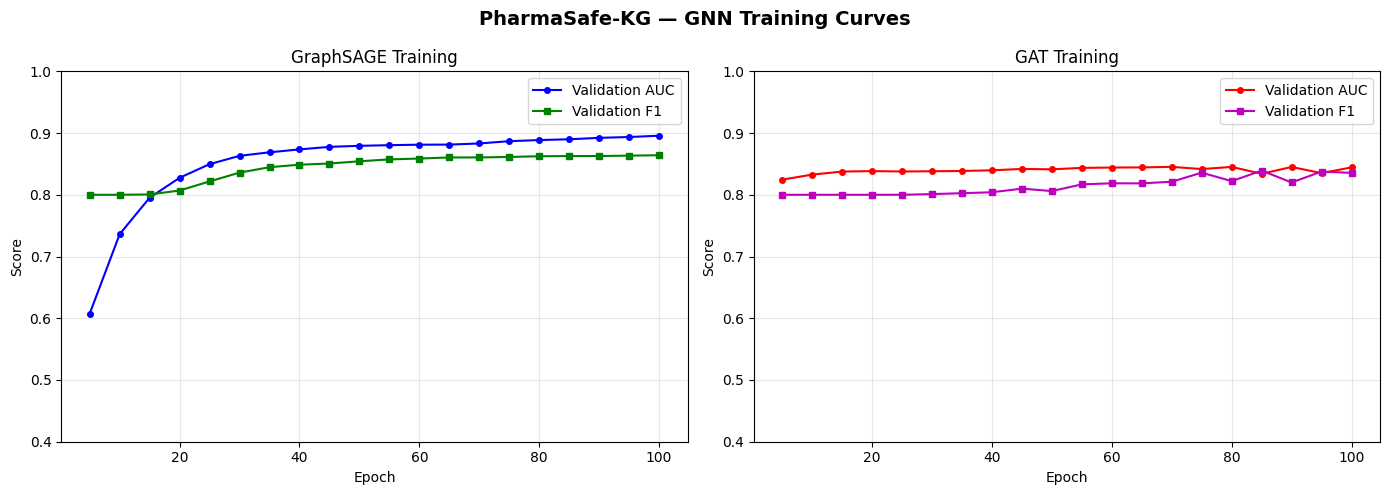

  Saved → training_curves.png  (use in IEEE paper Figure 3)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PharmaSafe-KG — GNN Training Curves", fontsize=14, fontweight="bold")

# GraphSAGE
ax1 = axes[0]
epochs_x = list(range(5, 5 * len(sage_history["val_auc"]) + 1, 5))
ax1.plot(epochs_x, sage_history["val_auc"], "b-o", label="Validation AUC", markersize=4)
ax1.plot(epochs_x, sage_history["val_f1"],  "g-s", label="Validation F1",  markersize=4)
ax1.set_title("GraphSAGE Training", fontsize=12)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Score")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.4, 1.0])

# GAT
ax2 = axes[1]
epochs_x2 = list(range(5, 5 * len(gat_history["val_auc"]) + 1, 5))
ax2.plot(epochs_x2, gat_history["val_auc"], "r-o", label="Validation AUC", markersize=4)
ax2.plot(epochs_x2, gat_history["val_f1"],  "m-s", label="Validation F1",  markersize=4)
ax2.set_title("GAT Training", fontsize=12)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.4, 1.0])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved → training_curves.png  (use in IEEE paper Figure 3)")

In [ ]:
# Save GraphSAGE (primary deployment model)
sage_path = f"{OUTPUT_DIR}/graphsage_weights.pt"
torch.save({
    "model_state_dict":  sage_model.state_dict(),
    "model_class":       "GraphSAGE_DDI",
    "in_channels":       graph_data.x.shape[1],
    "hidden":            128,
    "out":               64,
    "num_nodes":         num_nodes,
    "test_auc":          sage_auc,
    "test_f1":           sage_f1,
    "node_names":        nodes_df["name"].tolist(),
}, sage_path)
print(f"  ✅ GraphSAGE weights saved → {sage_path}")

# Save GAT (for paper comparison)
gat_path = f"{OUTPUT_DIR}/gat_weights.pt"
torch.save({
    "model_state_dict": gat_model.state_dict(),
    "model_class":      "GAT_DDI",
    "in_channels":      graph_data.x.shape[1],
    "hidden":           64,
    "out":              32,
    "heads":            4,
    "num_nodes":        num_nodes,
    "test_auc":         gat_auc,
    "test_f1":          gat_f1,
    "node_names":       nodes_df["name"].tolist(),
}, gat_path)
print(f"  ✅ GAT weights saved → {gat_path}")

# Save node embeddings for fast inference
sage_model.eval()
with torch.no_grad():
    embeddings = sage_model.encode(graph_data.x, graph_data.edge_index)
emb_path = f"{OUTPUT_DIR}/node_embeddings.pt"
torch.save({
    "embeddings":  embeddings.cpu(),
    "node_names":  nodes_df["name"].tolist(),
    "node_to_idx": {name: i for i, name in enumerate(nodes_df["name"].tolist())},
}, emb_path)
print(f"  ✅ Node embeddings saved → {emb_path}")

print("\n" + "═"*55)
print("  TRAINING COMPLETE")
print()
print("  Download these files to pharmasafe-kg/phase4/:")
print(f"  ✅ graphsage_weights.pt   (FastAPI inference model)")
print(f"  ✅ gat_weights.pt         (paper comparison)")
print(f"  ✅ node_embeddings.pt     (fast inference cache)")
print(f"  ✅ training_curves.png    (IEEE paper Figure 3)")
print("═"*55)


  ✅ GraphSAGE weights saved → /content/drive/MyDrive/pharmasafe-kg/model_output/graphsage_weights.pt
  ✅ GAT weights saved → /content/drive/MyDrive/pharmasafe-kg/model_output/gat_weights.pt
  ✅ Node embeddings saved → /content/drive/MyDrive/pharmasafe-kg/model_output/node_embeddings.pt

═══════════════════════════════════════════════════════
  TRAINING COMPLETE

  Download these files to pharmasafe-kg/phase4/:
  ✅ graphsage_weights.pt   (FastAPI inference model)
  ✅ gat_weights.pt         (paper comparison)
  ✅ node_embeddings.pt     (fast inference cache)
  ✅ training_curves.png    (IEEE paper Figure 3)
═══════════════════════════════════════════════════════
